### __Group Assignment - Predicting Airbnb Listing Prices in Melbourne, Australia__

**Competition Rankings**

The rankings for the competition are determined through two different leaderboards:

- **Public Leaderboard Ranking**: Available during the competition, these rankings are calculated based on 50% of the test dataset, which includes 1,500 observations. This allows participants to see how they are performing while the competition is still ongoing.
- **Final Leaderboard Ranking**: These rankings are recalculated from the other 50% of the test dataset, which consists of the remaining 1,500 observations, and are revealed 5 minutes after the competition concludes. This final evaluation determines the ultimate standings of the competition.



**Marks**

- Assignment: 30 marks consisting of Solutions (27 marks) + Video Presentation (3 marks)
- **Each Student's Mark: 50% x overall assignment mark + 50% x mark for the task that you are responsible for**  


---
---

### <span style="background-color: yellow;">**Fill out the following information**

- Team Name on Kaggle: `NGUYENANHCHAU`
- Team Leader and Team Member 1: `XUAN NGUYEN TRINH`
- Team Member 2: `MINH CHAU VU`
- Team Member 3: `THU ANH PHUNG`

---

## Task 1: Problem Description and Initial Data Analysis

- You must clearly explain all your answers in both the Markdown file and the recorded video.

**Total Marks: 9**   

Based on the Competition Overview, datasets and additional information provided on Kaggle, along with insights gained from personal research of the topic, write **Problem Description** (about 500 words) focusing on the sections listed below:
1. Forecasting Problem - explain what we are trying to do and how it could be used in the real world, e.g. who and how may benefit from it (2 marks)    
2. Evaluation Criteria - discuss the criterion that is used in this competition to assess forecasting performance, and its pros and cons. (2 marks)     
3. Categorise all variables provided in the dataset according to their type; Hint: similar to what we had in Programming Task 1 (2 marks)  
4. Missing Values - explain what you find for both the training and test datasets at this stage (2 marks)
5. Provide and discuss some interesting *univariate* data characteristics (e.g. summary statistics and plots) in the training dataset  (1 marks)       
- Hints:
    - You should **not** discuss any specific predictive algorithms at this stage


Student in charge of this task: `MINH CHAU VU`

## 1, Forecasting Problem

Our objective is predicting the prices (target) of Airbnb listings in Melbourne, Australia, using characteristics (features) in the provided Airbnb dataset. Analytical techniques, including handling missing values, cleaning data, and feature transformation will be performed for predictive modelling preparation. The ultimate goal is to create **accurate price estimating model**, which performs real-world relevance and serves **four main stakeholders**: **hosts**, **travellers**,**Airbnb**, and **property investors and analysts**. Hosts could use the estimation to better price their listings and maximise revenue, meanwhile travellers could better evaluate these listings to get fair and transparent pricing. For Airbnb, predictions could be used to create optimal pricing suggestions and foster platform trust. Regarding investors and analysts, the forecasted prices are useful in understanding a property rental potential and evaluating market dynamics.

## 2. Evaluation Metric

The main metric for performance evaluation is **Mean Absolute Error**. MAE has the formula:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$


Where:

n is the total number of observations

yᵢ is the actual price

ŷᵢ is the predicted price

**Mean Absolute Error** characterises the alterations between actual and predicted prices and it is defined as the mean of total alterations of the dataset.

Using MAE is advantageous because it is mathematically simple to calculate, even in large-scale applications. Also, MAE is transparent when using the same unit as the target variable and is less sensitive to outliers compared to RMSE.

However, on the other hand, MAE treats all errors equally, which may underrepresent the significance of large errors, potentially underperforming when predicting high-value listings. MAE also does not provide insights into the distribution of the errors that may be important in model evaluation.



## 3. Categorise the variables

**Table: Variable Types in the Dataset**

| Variable Kind | Number of Features | Feature Names |
|---------------|--------------------|----------------|
| Numeric       | 37                 | `longtitude`, `latitude`, `accommodates`, `host_listings_count`,  `calculated_host_listings_count`, `calculated_host_listings_count_entire_homes`,`calculated_host_listings_count_private_rooms`, `calculated_host_listings_count_shared_rooms`,`reviews_per_month`, `availability_30`, `availability_60`, `availability_90`, `availability_365`, `number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_l30d`, `minimum_nights`, `maximum_nights`, `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`, `bedrooms`, `beds`, `host_response_rate`, `host_acceptance_rate`, `bathrooms`, `review_scores_rating`, `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_communication`, `review_scores_location`, `review_scores_value`, `review_scores_accuracy`, `price`   | Numeric       | 14                 |     |    |
| Ordinal    | 1                 | `host_response_time`   | Numeric       | 14                 |     |    |
| Binary     |5         |`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `has_availability`, `instant_bookable`  |
| Nominal    |11         |`source`,  `host_name`, `host_location`, `host_neighbourhood`, `host_verifications`, `neighbourhood`, `neighbourhood_cleansed`, `property_type`, `room_type`, `amenities`,`ID`  |
 Text    |4         |`description`, `neighbourhood_overview`, `host_about`, `name` |
| Date   |3        |`host_since`, `first_review`, `last_review`  |



## 4. Missing Value

In [ ]:
import pandas as pd
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Load the dataset
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Checking for missing values in both training and test datasets
train_missing_values = train_data.isnull().sum()
test_missing_values = test_data.isnull().sum()

# Display columns with missing values
train_missing = train_missing_values[train_missing_values > 0]
test_missing = test_missing_values[test_missing_values > 0]

print("Missing values in the training dataset:")
print(train_missing)

print("\nMissing values in the test dataset:")
print(test_missing)

Missing values in the training dataset:
name                              1
description                      57
neighborhood_overview          1823
host_location                  1280
host_about                     2270
host_acceptance_rate             63
host_neighbourhood             3460
neighbourhood                  1823
neighbourhood_cleansed          108
property_type                    84
room_type                       134
bathrooms                         6
bedrooms                        378
beds                             72
minimum_minimum_nights           45
maximum_maximum_nights           45
availability_365                 47
review_scores_accuracy           22
review_scores_cleanliness        22
review_scores_checkin            22
review_scores_communication      22
review_scores_location           22
review_scores_value              22
dtype: int64

Missing values in the test dataset:
description                      31
neighborhood_overview          1424
host_locat

**Train dataset**: The most missing values found in the `host_neighbourhood` variable (3460), followed by `host_about` (2270), `neighbourhood_overview` (1823), `neighbourhood`(1823) and `host_location` (1280). Variables with relatively significant missing values include `bedrooms` (378), `room_type` (134) and `neighbourhood_cleansed` (108). Other variables have inconsiderable number of missing values of under 100, with the least number of missing values belong to `bathrooms` variable with 6 omissions

**Test dataset**: The test dataset showcases similar missing trend with highest missingness found in `host_neighbourhood` with 2066 values, followed by `host_about` (1441), `neighbourhood_overview` and `neighbourhood`(1424). Notably, review-related fields, such as `review_score_rating` and `review_score_value`, have between 250 to 300 missing values. The variables with the least missing values are `minimum_minimum_nights`,`maximum_maximum_nights`(10) and `host_is_superhost` (only 2 missing values).

## 5. Provide and discuss interesting univariate data characteristics

In [ ]:
train_data['price'] = train_data['price'].replace('[\$,]', '', regex=True).astype(float)
train_data.describe()

,ID,host_listings_count,latitude,longitude,accommodates,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,6622.000000,6928.000000,7000.000000,7000.00000,6955.000000,...,6978.000000,6978.000000,6978.000000,6978.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3499.500000,15.625571,-37.826139,145.039399,3.839714,1.785865,2.263568,4.316000,712.17500,3.787779,...,4.820373,4.831680,4.844008,4.681164,13.557143,9.212571,4.270429,0.030286,1.465427,285.649714
std,2020.870275,41.600059,0.080672,0.181751,2.514657,1.056360,1.783209,17.898345,503.66911,11.106491,...,0.316198,0.328098,0.249277,0.358105,39.169801,17.993489,28.316711,0.309302,1.630973,2325.453324
min,0.000000,1.000000,-38.224110,144.517800,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000,25.000000
25%,1749.750000,1.000000,-37.856415,144.956993,2.000000,1.000000,1.000000,1.000000,90.00000,1.000000,...,4.780000,4.810000,4.800000,4.600000,1.000000,1.000000,0.000000,0.000000,0.400000,117.000000
50%,3499.500000,3.000000,-37.818565,144.980060,4.000000,1.000000,2.000000,2.000000,1125.00000,2.000000,...,4.910000,4.930000,4.900000,4.760000,2.000000,1.000000,0.000000,0.000000,1.000000,172.000000
75%,5249.250000,9.000000,-37.800105,145.056391,5.000000,2.000000,3.000000,3.000000,1125.00000,3.000000,...,4.980000,4.990000,4.970000,4.880000,7.000000,6.000000,1.000000,0.000000,2.050000,268.000000
max,6999.000000,292.000000,-37.486450,145.831410,16.000000,14.000000,22.000000,1125.000000,10000.00000,360.000000,...,5.000000,5.000000,5.000000,5.000000,290.000000,118.000000,224.000000,6.000000,34.090000,145160.000000


The description table shows some interesting characteristics:

- The majority of listings priced between $100$ to $300$, with the mean of approximately $285.65. The maximum value (145,160) is significantly different from how prices commonly range, suggesting outliers that inflate both the mean and standard deviation.

- Other numerical features, such as 'bedrooms' and 'accommodates', reflect typical characteristics of common Airbnb properties - most listings have 1-2 bedrooms and can accommodate 2-5 guests, aligning with common short-term rental use cases

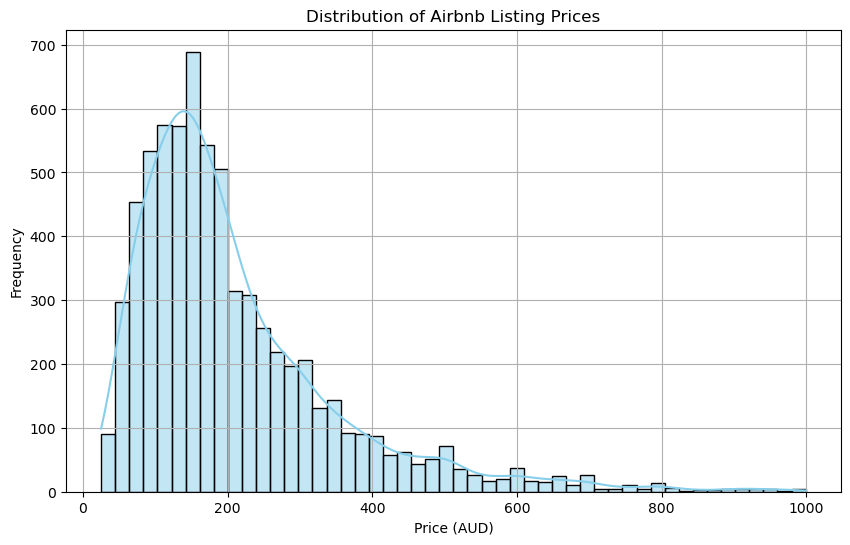

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

filtered_prices = train_data[train_data['price'] < 1000]['price']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_prices, bins=50, color='skyblue', edgecolor='black', kde=True)
plt.title('Distribution of Airbnb Listing Prices')
plt.xlabel('Price (AUD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- The histogram shows a right-skewed distribution. The majority of listings cluter between 100 and 300 with the peak at 150. The frequency drops off significantly beyond 400 and stablised when reaching $1000 and above, making a long tail. The concentration within lower range Airbnb listings suggest the market segment is budget-concious, preferring affordable accomodation when travelling.

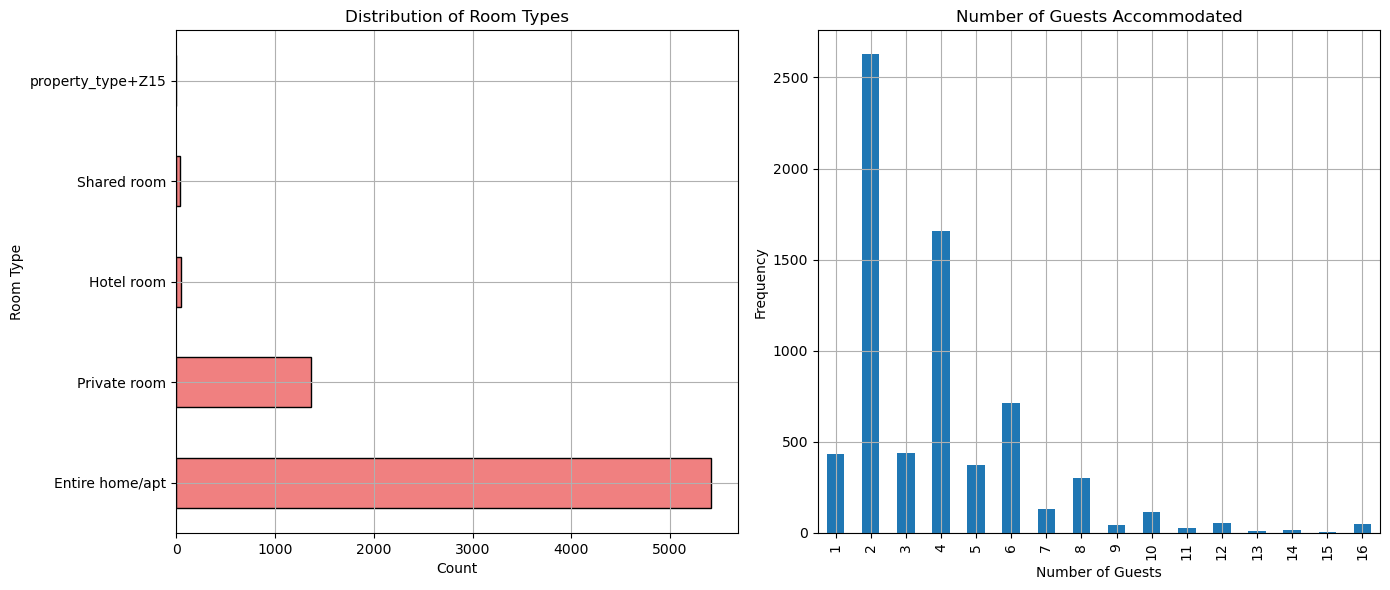

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Plot 1: Room Type Distribution (horizontal bar)
room_counts = train_data['room_type'].value_counts()
room_counts.plot(kind='barh', color='lightcoral', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Room Types')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Room Type')
axes[0].grid(True)

# Plot 2: Accommodates (number of guests)
train_data['accommodates'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Number of Guests Accommodated')
axes[1].set_xlabel('Number of Guests')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.tight_layout()

plt.show()

- **'Entired home/apt'** is the most common room type, followed by **'private room'**, which far outnumbered the other accommodation types. This indicates that most Airbnb listings offer full properties or private spaces rather than shared spaces, which may influence pricing.

- Another variables relevant for prices is **'accommodates'**, which showcases the number of guests the listings can host. Most of the listings could accommodate 2-4 guests, and the frequency plummets as capacity increases. This aligns with short-term travel needs which require smaller and personal spaces

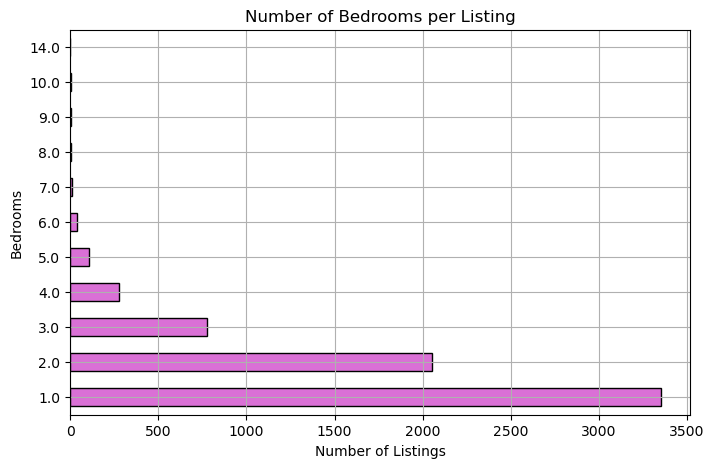

In [ ]:
bedroom_counts = train_data['bedrooms'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bedroom_counts.plot(kind='barh', color='orchid', edgecolor='black')
plt.title('Number of Bedrooms per Listing')
plt.xlabel('Number of Listings')
plt.ylabel('Bedrooms')
plt.grid(True)
plt.show()

- The bar chart indicates that most listings have 1 to 2 bedrooms, and listings with more than 6 bedrooms are very rare. This aligns with typical listing options in Melbourne. Since fewer bedrooms offer more limited accommodating capacity, which correlates with lower price ranges.

---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

- You must clearly explain all your answers in both the Markdown file and the recorded video.

**Total Marks: 9**

Student in charge of this task: `THU ANH PHUNG`

**Task 2, Question 1**: Clean **all** numerical features so that they can be used in training algorithms. For instance, `host_response_rate` feature is in object format containing both numerical values and text. Extract numerical values (or equivalently eliminate the text) so that the numerical values can be used as a regular feature.  
(2 marks)

In [ ]:
def clean_rate(df, col):
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace('%', '', regex=False)
    df[col] = df[col].str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')


for col_name in ['host_response_rate', 'host_acceptance_rate']:
    if col_name in train_data.columns:
        clean_rate(train_data, col_name)
    if col_name in test_data.columns:
        clean_rate(test_data, col_name)



**Code explanation**

**1.Define `clean_rate` function**:

We first have the **input** of dataframe as `df` and a column name `col`

- **Convert to String and Trim Whitespace** : By using `astype(str)`, we convert all data in specified columns to type string to ensure uniformity of data. Extra spaces are removed using `str.strip()`.

- **Remove unessential signs**: We use `str.replace()` to convert any symbols ('%', '$', ',') that hinder data from numerical analysis.

- **Convert to numeric**: `pd.to_numeric()` is used to convert the cleaned string values to numeric. `errors = 'coerce'` helps convert any invalid data into NaN safely.

**2. Apply `clean_rate` function to relevant columns**

- We targeted two measurement columns that contain units, including `host_response_rate` and `host_acceptance_rate` to apply the function.

- We looped through the list of targeted columns to check if columns exist in the train dataset and test dataset to apply the cleaning function



**Task 2, Question 2** Create at least 4 new features from existing features which contain multiple items of information.   
(2 marks)

In [ ]:
# Create a list of review-related columns
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

# Create new features
def create_features(df):
    # 1. Average review score
    df['average_review_score'] = df[review_cols].mean(axis=1)

    # 2. Number of amenities
    df['num_amenities'] = df['amenities'].apply(lambda x: len(x.strip('{}').split(',')) if pd.notnull(x) else 0)

    # 3. Night range
    df['night_range'] = df['maximum_nights'] - df['minimum_nights']

    # 4. Host experience years
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_experience_years'] = (2025 - df['host_since'].dt.year).astype('Int64')  # allow NaNs with Int64

    # 5. Combined neighbourhood
    df['combined_neighbourhood'] = (
        df['neighbourhood_cleansed']
        .fillna(df['host_neighbourhood'])
        .fillna(df['neighbourhood'])
    )

    # 6. Days since first review
    df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
    df['days_since_first_review'] = (pd.Timestamp("2025-01-01") - df['first_review']).dt.days.astype('Int64')

    # 7. Days since last review
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    df['days_since_last_review'] = (pd.Timestamp("2025-01-01") - df['last_review']).dt.days.astype('Int64')

# Apply to both train and test
create_features(train_data)
create_features(test_data)

# Drop source columns now embedded in new features
drop_cols = review_cols + [
    'amenities', 'host_since',
    'neighbourhood_cleansed', 'host_neighbourhood', 'neighbourhood',
    'first_review', 'last_review'
]
train_data.drop(columns=drop_cols, inplace=True)
test_data.drop(columns=drop_cols, inplace=True)

# Confirm changes
train_data.head()

,ID,source,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_time,host_response_rate,...,calculated_host_listings_count_shared_rooms,reviews_per_month,price,average_review_score,num_amenities,night_range,host_experience_years,combined_neighbourhood,days_since_first_review,days_since_last_review
0,0,city scrape,"The Stables, Richmond",Superbly located hotel style accommodation in ...,Richmond is a great neighbourhood. A beautifu...,Ione,"Melbourne, Australia",I'm a working mum who loves being able to shar...,within an hour,100,...,0,6.11,132.0,4.911429,38,12,12,Yarra,4296,683
1,1,city scrape,Room in Cool Deco Apartment in Brunswick East,A large air conditioned room with firm queen s...,This hip area is a crossroads between two grea...,Lindsay,"Melbourne, Australia",As an artist working in animation and video I ...,within a few hours,100,...,0,1.37,39.0,4.535714,57,23,16,Moreland,4372,665
2,2,city scrape,The Suite @ Angelus Retreat,<b>The space</b><br />Welcome to ANGELUS Retre...,NaN,Margaret Jiin,"Melbourne, Australia",I have very special interests in Life and Life...,within a few hours,100,...,0,0.09,270.0,4.787143,21,363,14,Yarra Ranges,3467,933
3,3,city scrape,Million Dollar Views Over Melbourne,<b>The space</b><br /><b>Enjoy Million Dollar ...,NaN,Paul,"Melbourne, Australia",Professional couple who enjoy entertaining in ...,within a day,75,...,0,0.01,1000.0,4.285714,13,729,15,Melbourne,4826,4723
4,4,city scrape,Melbourne - Old Trafford Apartment,After hosting many guests from all over the wo...,Our street is quiet & secluded but within walk...,Daryl & Dee,"Berwick, Australia",We are an active couple who work from home and...,within a few hours,100,...,0,1.43,116.0,4.908571,49,13,15,"Berwick, Victoria, Australia",5152,670


**Code Explanation**

**1. Define `create_features` function**

Using **`def create_features(df)`**, we define some new feature

- **Average review score**:

   -  We define a list named `review_cols` containing all the columns related to review scores, such as accuracy, rating, cleanliness. These columns contains different aspects of review scores used to compute summary feature.

   - Calculates the means of review score columns using `.mean(axis = 1)`.

- **Number of amenities**: Counts the number of amenities listed per property by removing the curly braces `({})` and splitting the string by commas

- **Night Range**: Computes the range between minimum nights and maximum nights that a guest can stay

- **Host experience year**: Converts `host_since` to datetime format using `pd.to_datetime()` and subtracts the year the host start from 2025 to calculate experiences in years

- **Combined neighbourhood**: Fills in missing values in `neighbourhood_cleansed` by data from columns `host_neighbourhood` and `neighbourhood` using `fillna()`

- **Days since first review**: Converts the `first_review` column to datetime format using `pd.to_datetime()` to calculate how many days passed since the first review.

- **Day since last review**: Converts the `first_review` column to datetime format using `pd.to_datetime()` to calculate how many days passed since the last review.

**2. Apply the function to datasets**

**3.Remove the source columns**:
To reduce redundancy, original columns used to create new features are dropped using `.drop()`.

**Task 2, Question 3**: Impute the missing values for all features in both the training and test datasets.   
(2 marks)

In [ ]:
from sklearn.impute import SimpleImputer

# Identify columns
num_train = train_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'price' in num_train:
    num_train.remove('price')
cat_train = train_data.select_dtypes(include=['object']).columns.tolist()

# Numerical Imputer
num_imputer = SimpleImputer(strategy='median')
train_data[num_train] = num_imputer.fit_transform(train_data[num_train])
test_data[num_train] = num_imputer.transform(test_data[num_train])

# Categorical Imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
train_data[cat_train] = cat_imputer.fit_transform(train_data[cat_train])
test_data[cat_train] = cat_imputer.transform(test_data[cat_train])

### **Code Explanation**

**1. Column Identification**

- Different imputation strategies are needed for numeric vs. categorical data. The target variable ('price') should not be imputed to avoid data leakage.

**2. Numerical Imputation**

- The code uses median imputation for numeric features, replacing missing values with the median of each column. This method is robust against outliers and preserves the dataset's statistical properties.

**3. Categorical Imputation**

- For categorical features, mode imputation is employed, replacing missing values with the most frequent category. This ensures that the imputed values reflect the data's distribution.


**Task 2, Question 4**: Encode all categorical variables appropriately as discussed in class.

- Where multiple values are given for an observation encode the observation as 'other'.
- Where a categorical feature contains more than 5 unique values, map the features into 5 most frequent values + 'other' and then encode appropriately.  
(2 marks)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# === Separate column types ===
categorical_cols = train_data.select_dtypes(exclude=['float64', 'int64']).columns.tolist()
numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# === Clean all categorical columns ===
for col in categorical_cols:
    # Step 1: Convert multi-value cells to 'other'
    train_data[col] = train_data[col].apply(lambda x: 'other' if isinstance(x, str) and ',' in x else x)
    test_data[col] = test_data[col].apply(lambda x: 'other' if isinstance(x, str) and ',' in x else x)

    # Step 2: Remove columns with all unique values
    train_data = train_data.loc[:, train_data.nunique() < len(train_data)]

    # Step 3: Keep top 5 frequent categories, map others to 'other'
    top_5 = train_data[col].value_counts().nlargest(5).index
    train_data[col] = train_data[col].apply(lambda x: x if x in top_5 else 'other')
    test_data[col] = test_data[col].apply(lambda x: x if x in top_5 else 'other')

# === Ensure all categoricals are strings ===
train_data[categorical_cols] = train_data[categorical_cols].astype(str)
test_data[categorical_cols] = test_data[categorical_cols].astype(str)

# === One-hot and ordinal column sets ===
one_hot = ['host_location', 'property_type', 'room_type']
ordinal = ['combined_neighbourhood', 'host_is_superhost', 'host_verifications',
           'host_identity_verified', 'has_availability', 'instant_bookable','host_has_profile_pic']

# === One-hot encode selected columns ===
train_data = pd.get_dummies(train_data, columns=one_hot, drop_first=False)
test_data = pd.get_dummies(test_data, columns=one_hot, drop_first=False)

# === Ordinal encode selected columns ===
train_data[ordinal] = train_data[ordinal].astype(str)
test_data[ordinal] = test_data[ordinal].astype(str)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_data[ordinal] = encoder.fit_transform(train_data[ordinal])
test_data[ordinal] = encoder.transform(test_data[ordinal])

# === Align test data to train columns ===
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

In [ ]:
#MANUAL REMAP
# === Manual mapping for 'host_response_time' ===
response_time_map = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1,
    'other': 0
}

# Fill missing and map
train_data['host_response_time'] = train_data['host_response_time'].fillna('other').map(response_time_map)
test_data['host_response_time'] = test_data['host_response_time'].fillna('other').map(response_time_map)


#Bathroom Mapping
import re
def map_bathroom_string(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).lower()

    # Half-bath (private or not)
    if 'half-bath' in value:
        if 'shared' in value:
            return 0.25  # Half of a half bath
        else:
            return 0.5   # Regular half bath

    # Extract number from the string (e.g., "1.5 shared baths")
    match = re.search(r'[\d.]+', value)
    num = float(match.group()) if match else 0.0

    # If shared, it counts for half
    if 'shared' in value:
        return num * 0.5
    else:
        return num

# Apply to both train and test sets
train_data['bathrooms_mapped'] = train_data['bathrooms'].apply(map_bathroom_string)
test_data['bathrooms_mapped'] = test_data['bathrooms'].apply(map_bathroom_string)

# Delete old column
train_data.drop(columns=['bathrooms'], inplace=True)
test_data.drop(columns=['bathrooms'], inplace=True)


### **Code Explanation**

**1. Separate Categorical and Numeric Columns and clean all categorical column**

- Categorical variables need to be encoded, while numeric ones usually don’t so we seperate them. We clean the categorical column within 3 steps: Handle Multi-Value Cells, Drop Columns with All Unique Values and Keep Only Top 5 Categories + 'other'.

**2. Convert All Categoricals to Strings and Define Norminal and Ordinal Columns**

- Encoding methods expect string inputs. This ensures all categorical columns are treated consistently. We choose which columns to one-hot encode (suitable for unordered categories) and which to ordinal encode (ordered or binary categories).

**3. One-hot Encode for Norminal variables**

- One-hot encoding turns each category into its own binary column. We keep all columns (no drop_first) to avoid losing any category.

**4. Ordinal Encoder for Ordinal variables**

- Ordinal encoding assigns numeric codes to categories.
We convert the columns to string first, so encoding doesn’t break. `handle_unknown='use_encoded_value', unknown_value=-1` ensures new/unseen categories in test data are handled gracefully.

**5. Manual mapping for `host_response_time` and `bathrooms`**

- Converts textual response time descriptions into numerical scores for machine learning. We use the logic: Faster responses get higher scores (4=best, 0=missing/other) and replaces nulls with 'other' before mapping.
- The `bathrooms` feature contains inconsistent descriptions (e.g., "1.5 shared baths", "half-bath"). We standardizes it into numerical values to handles edge cases like shared or half bathrooms logically.
- The key outcome of manual mapping:

  `host_response_time`: Ordinal scores (0-4) for model compatibility.

  `bathrooms_mapped`: Logical numerical values:
   
   * 1.0 = 1 private full bath
   * 0.5 = 1 private half-bath OR 1 shared full bath
   * 0.25 = 1 shared half-bath


**Task 2, Question 5**: Perform any additional data preparation steps you consider necessary before building your predictive models, and clearly explain each action you take.  
(1 mark)

In [ ]:
# 1. Sentiment analysis
from textblob import TextBlob

# Fill missing values with empty strings
for col in ['name', 'description', 'host_about','neighborhood_overview']:
    train_data[col] = train_data[col].fillna('')
    test_data[col] = test_data[col].fillna('')

    # Sentiment polarity (from -1 to 1)
    train_data[f'{col}_sentiment'] = train_data[col].apply(lambda x: TextBlob(x).sentiment.polarity)
    test_data[f'{col}_sentiment'] = test_data[col].apply(lambda x: TextBlob(x).sentiment.polarity)

    # Subjectivity (from 0 to 1, 0 = objective, 1 = subjective)
    train_data[f'{col}_subjectivity'] = train_data[col].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    test_data[f'{col}_subjectivity'] = test_data[col].apply(lambda x: TextBlob(x).sentiment.subjectivity)


# Drop transformed data
train_data.drop(columns=['name', 'description', 'host_about','neighborhood_overview'], inplace=True)
test_data.drop(columns=['name', 'description', 'host_about','neighborhood_overview'], inplace=True)

In [ ]:
# 2. Feature Scaling

# Standart Scaler
from sklearn.preprocessing import StandardScaler

numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Create a copy of numeric_cols without 'price'
numeric_features = [col for col in numeric_cols if col != 'price']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform training data (excluding price)
train_data[numeric_features] = scaler.fit_transform(train_data[numeric_features])

# Transform test data (use same scaler)
test_data[numeric_features] = scaler.transform(test_data[numeric_features])

train_data.head()

,source,host_name,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,room_type_property_type+Z15,bathrooms_mapped,name_sentiment,name_subjectivity,description_sentiment,description_subjectivity,host_about_sentiment,host_about_subjectivity,neighborhood_overview_sentiment,neighborhood_overview_subjectivity
0,city scrape,other,0.502908,0.289286,0.458070,-0.870834,-0.327561,0.22942,0.046341,0.211604,...,False,-0.075763,-0.063762,0.039174,-0.038762,-0.016366,-0.090546,-0.074842,-0.052903,-0.02031
1,city scrape,other,-0.946992,0.289286,0.458070,-0.870834,-0.351601,0.22942,0.046341,0.211604,...,False,-0.961143,-0.063762,0.039174,-0.038762,-0.016366,-0.090546,-0.074842,-0.052903,-0.02031
2,city scrape,other,-0.946992,0.289286,-0.517838,1.148324,-0.327561,0.22942,0.046341,0.211604,...,False,-1.846523,-0.063762,0.039174,-0.038762,-0.016366,-0.090546,-0.074842,-0.052903,-0.02031
3,city scrape,other,-2.396891,-1.523091,0.165298,-0.870834,-0.279480,0.22942,0.046341,0.211604,...,False,-1.846523,-0.063762,0.039174,-0.038762,-0.016366,-0.090546,-0.074842,-0.052903,-0.02031
4,city scrape,other,-0.946992,0.289286,-0.078679,1.148324,-0.351601,0.22942,0.046341,0.211604,...,False,-0.075763,-0.063762,0.039174,-0.038762,-0.016366,-0.090546,-0.074842,-0.052903,-0.02031


In [ ]:
# 3. Clean columns

# Define a function to clean column names
def clean_column_names(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace('[^A-Za-z0-9_]', '_', regex=True)
        .str.replace('__+', '_', regex=True)
        .str.lower()
    )
    return df

# Apply to both df and df_test
train_data = clean_column_names(train_data)
test_data = clean_column_names(test_data)

In [ ]:
# 4. Remove unrelated column

unrelated_col = ['source','host_name']

train_data.drop(unrelated_col,axis =1, inplace =True)
test_data.drop(unrelated_col,axis =1, inplace =True)


## **Code explanation**

**1. Sentiment Analysis**:
- Imports  `TextBlob` from skicit-learn
  
- Fills the missing values in text columns (`name`, `description`, `host_about`, `neighbourhood_overview`) with empty strings to avoid errors.

- Applys TextBlob to extract:

     - **Polarity**: Captures emotional tone, ranging from -1(negative) to 1 (positive)
     - **Subjectivity**: Measures opinions versus fact, ranging from 0 (objective) to 1 (subjective)

- Original columns are dropped to reduce dimensionality


**2.Feature Scaling**

- Imports `StandardScaler` from skicit-learn

- We identify columns in numeric forms (float, integer) and exclude the target variable (`price`)

- `StandardScaler` is then applied on train dataset to standardise each feature to have mean = 0 and standard deviation = 1. The standardisation is fitted on train data and applied to test data to prevent data leakage.

**3. Clean column names**

- Defines a function `clean_columns_name`, which reformats the standardised columns to make sure they are all lowercase, free of special characters and consistently formatted with underscore.

- Applys the function on both train and test dataset

**4. Drop unrelated columns**:

- `host_name` and `source` are dropped from the dataset since these columns are non-informative and irrelevant for predicting.

**5.Export cleaned data**: The exported dataset is cleaned and ready to be used for modelling in the following task.


---
## Task 3: Fit and tune predictive models, submit predictions & win competition

- You must clearly explain all your answers in both the Markdown file and the recorded video.
-
**Total Marks: 9**

For this task, you should not create any new features and must rely on the variables constructed in Task 2.  


1. Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)

2. Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (2 marks)
   
3. Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

4. Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)

5. Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   

- Hints:
    - Make sure your Python code works so that your results can be replicated by the marker
    - You will receive the mark of zero for this Task if your code does not produce the forecasts uploaded to Kaggle



Student in charge of this task: `XUAN NGUYEN TRINH`

### 1. Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)


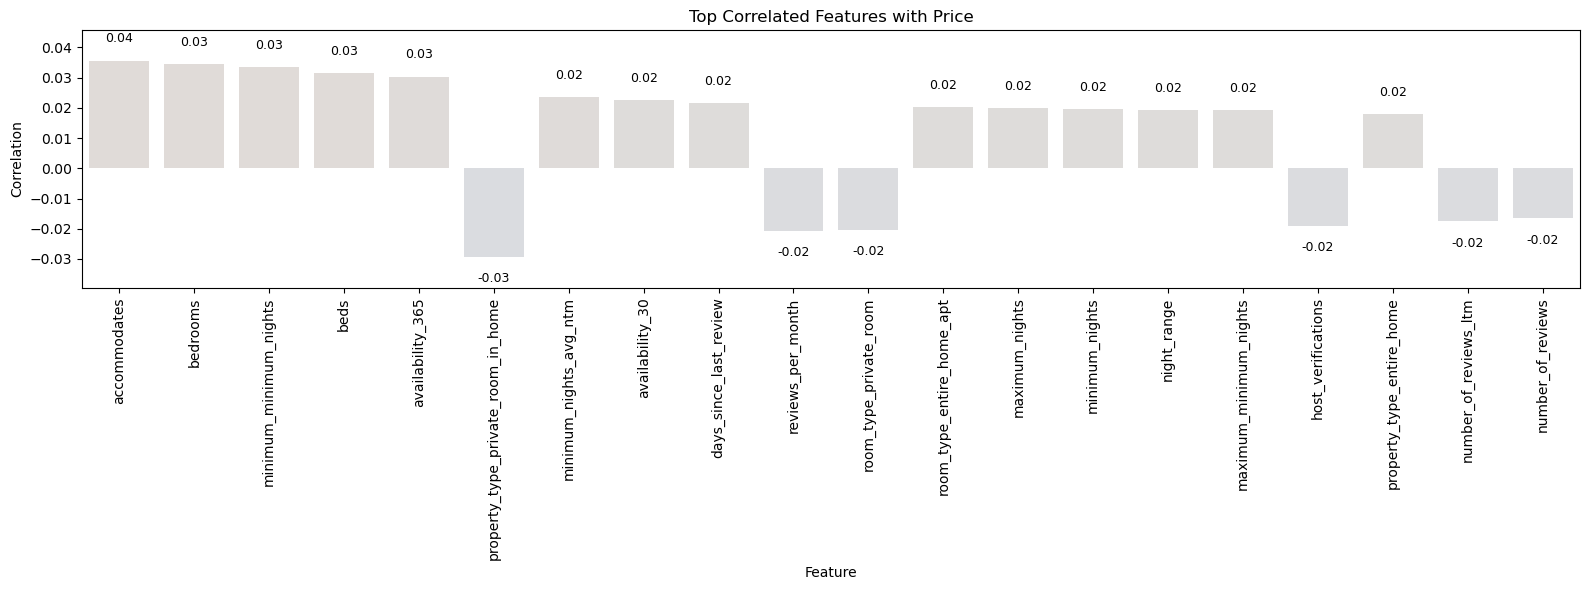

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

# Compute correlation with price
correlation = train_data.corr(numeric_only=True)['price'].drop('price')
correlation = correlation.reindex(correlation.abs().sort_values(ascending=False).index)  # sort by strength
correlation = correlation.head(20)  # top N features

# Color map
norm = colors.Normalize(vmin=-1, vmax=1)
cmap = cm.get_cmap('coolwarm')
mapped_colors = [cmap(norm(val)) for val in correlation.values]

# Plot
plt.figure(figsize=(16, 6))
sns.barplot(x=correlation.index, y=correlation.values, palette=mapped_colors)

# Annotate bars
for i, val in enumerate(correlation.values):
    plt.text(i, val + 0.005 * (1 if val >= 0 else -1), f"{val:.2f}", ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

plt.ylim(correlation.min() - 0.01, correlation.max() + 0.01)  # prevent squashing
plt.xticks(rotation=90)
plt.title('Top Correlated Features with Price')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

### Code Explanation: Correlation Plot with Price

- **Import Libraries:** `matplotlib`, `seaborn`, and `colors` are used for plotting and color mapping.
- **Compute Correlation:** Correlation between all numerical features and `price` is calculated.
- **Sort & Select Top Features:** The top 20 features are selected based on absolute correlation magnitude.
- **Plot Bar Chart:** A horizontal bar chart is drawn to show the correlation values with proper annotations.
- **Annotate Bars:** Each bar is labeled with the correlation coefficient for clarity.
- **Visual Tuning:** Limits, labels, and layout are adjusted for better visualization.

### Interpretation

The chart reveals that most features have relatively low linear correlation with the target variable `price`. The strongest positive associations are seen with `accommodates`, `bedrooms`, and `beds`, which intuitively aligns with expectations—properties that accommodate more guests or have more bedrooms tend to be priced higher. However, even these top correlations are modest, hovering around +0.03 to +0.04.

On the negative side, features like `number_of_reviews`, `reviews_per_month`, and certain categorical dummies show weak negative correlations with price. This may indicate that listings with more reviews or higher review frequency tend to be priced more competitively or belong to budget-friendly segments.

Overall, the weak correlation values suggest that individual features do not linearly drive price significantly. This underscores the need for more complex models (like tree-based methods) or richer feature interactions to effectively capture price variance in this dataset. It also motivates further feature engineering or dimensionality reduction to improve predictive performance.

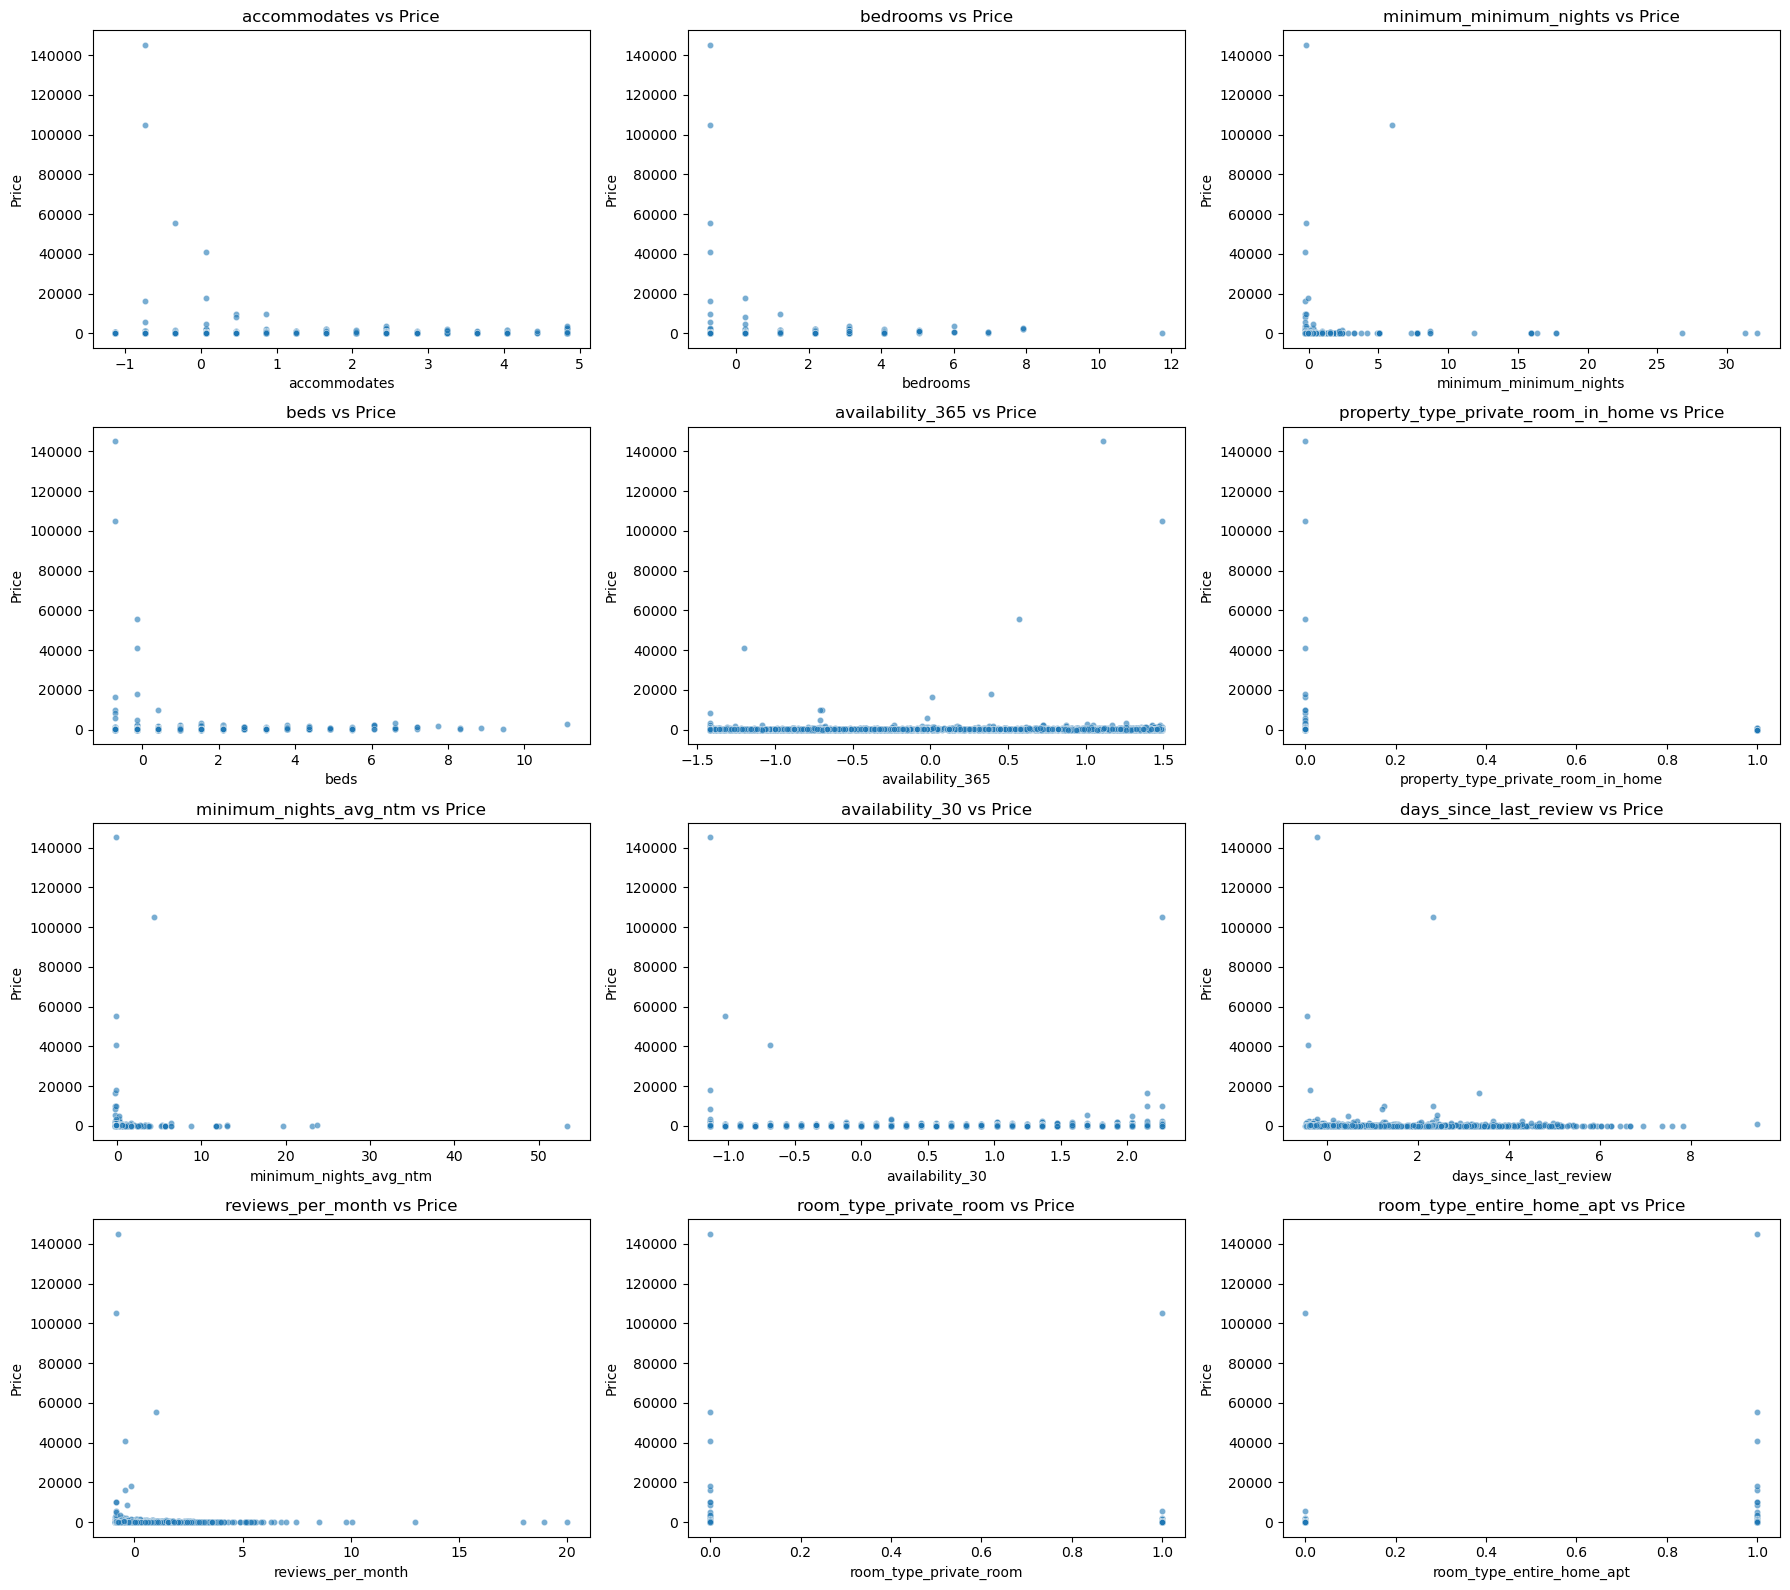

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get top 12 numeric features most correlated with price
correlation = train_data.corr(numeric_only=True)['price'].drop('price')
top_features = correlation.abs().sort_values(ascending=False).head(12).index.tolist()

# Step 2: Set grid size
n_cols = 3
n_rows = (len(top_features) + n_cols - 1) // n_cols

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

# Step 3: Plot scatter plots
for i, feature in enumerate(top_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(data=train_data, x=feature, y='price', alpha=0.6, s=20)
    plt.title(f"{feature} vs Price")
    plt.xlabel(feature)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

**Purpose:** This graph selects the top 12 numerical features most correlated with price and creates a matrix of scatter plots to visually inspect the relationship between each feature and the target variable.

- Observations:
    - Features like accommodates, bedrooms, and beds show a mild positive trend—higher values in these features tend to associate with higher prices, although the variance is large.
    - Features such as availability_365 and availability_30 show dense clustering at the lower price range, but with a few outliers contributing to a long right tail.
    - Some features (e.g., minimum_minimum_nights, minimum_nights_avg_ntm) exhibit a horizontal spread with little vertical movement, suggesting weak predictive power.
    - Binary-encoded features like property_type_private_room_in_home and room_type_private_room present distinct vertical groupings that imply discrete jumps in price based on property type, though again, with heavy noise and outliers.
    - Several plots reveal extreme outliers with prices exceeding 100,000, which skew the distribution and reinforce earlier findings that the dataset is heavily right-skewed.

### 2. Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (2 marks)



### A. Random Forest

Random Forest is an ensemple machine learning algorithm that uses multiple trees for better predictions. The results from each tree are combined by voting for classification and averaging outputs for regression. This model helps enhance prediction accuracy and overfitting.

- **How it works**:
  - Create decision trees: Each tree is trained on a bootstrapped sample of the data. Each tree looks at random part of the data.
  - Pick random features: At each split, only a subset of features are selected to make trees stay different from each other.
  - Combine the predictions:
     - For classification: We use majority voting to choose a category that most trees agree
     - For regression: Final prediction equals the average of all trees predictions.

- **Why we choose**:
    - Random Forest performs well on large and complex datasets, making it suitable for this task with 61 variables.  
    - It provides feature importance scores, helping identify the most relevant features for prediction.  
    - It is robust to outliers and less prone to overfitting compared to a single decision tree.  


### B. XBGBoost

- **Definition:** XGBoost is a Gradient Boosting algorithm, which builds trees sequentially so that each tree corrects the errors from the previous one. This method forms a strong model from multiple weak models.

- **How it works**

    - Start with a base learner: The first decision tree is trained on the data to produce prediction.

    - Calculate the errors: After the prediction, the error, which is the gap between the predicted and actual values is calculated

    - Train the next tree: The next tree is trained based on the previous tree with the calculated error. This helps improve accuracy for the error made in the first tree

    - Repeat the process: The process of adding trees and learning from the error to enhance performance is repeated until stopping criterion is met

    - Combine the predictions: The sum of predictions from all the trees are the final prediction of the model


- **Why we choose**

    - Highly tunable and regularised: XGBoost allows fine-grained control over model behavior through different parameters. It helps prevent overfitting, which is a risk in high-dimensional dataset like this.
    
    - Robustness to Irregularities and Noises: The Airbnb dataset may contain outliers, skewed distributions and missing or noisy values. The XGBoost is suitable since it robusts to such irregularities

### C. Ridge

- **Definition**: Ridge is the statistical regularisation technique. This model helps correct overfitting on training data by shrinking coefficient values and handle multicollinearity.

- **How it works**

Ridge regression modifies the traditional linear regression equation by adding a regularisation term. The objective of ridge regression model is to minimise the following cost function:

$J(w)=\sum_{i=1}^n\left(y_{i} - \hat{y}_{i}\right)^2 + \lambda||w||_2^2$

Jβ is the cost function that ridge regression aims to minimise.

yi: The actual value for iᵗʰ observation

ŷᵢ: The predicted value for iᵗʰ observation

$\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$: The sum of squared errors

$||w||_2^2$: The squared L2 norm of the weight vector

$\lambda$:  The regularization hyperparameter, which controls the penalty strength

- **Why we choose**:

   - Handles Multicollinearity:  Airbnb dataset contains many interrelated features, which are often highly correlated. Ridge is ideal for handle possible multicollinearity by shrinking correlated features

   - Bias - Variance Trade Off: Ridge regression balances the Bias-Variance trade-off. This model introduces the regularisation parameter, and by adjusting this, the model finds optimal balance between Bias and Variance, which prevents the model from both overfitting and underfitting. This balance is highly essential for high-dimensional Airbnb dataset.

   - Robust Baseline Model: Ridge effectively provides strong baseline for comparison as a regularised linear model











### Question 3. Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

**1. Split data**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Define X and y for regression model
X = train_data.drop(['price'], axis = 1)
y = train_data['price']
X_pred = test_data.drop('price', axis = 1) #For Result testing

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Code comment:** Firstly split the data into two sets, training and testing. By doing so, we could get a more reliable test result when applying our trained model on the testing set where there are new records of unseen data. In this test, we set the train size to be 80%, and the test size to be 20%

#### A. Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# Set up the model
rf = RandomForestRegressor(random_state=120)

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search with 5-fold CV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    verbose=0,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_
print("\n Best Hyperparameters:")
print(grid_rf.best_params_)

# Predictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

#Metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Output
print("\n Model Performance:")
print(f"MAE (Train): {mae_train:.2f}")
print(f"MAE (Test) : {mae_test:.2f}")
print(f"R²  (Train): {r2_train:.4f}")
print(f"R²  (Test) : {r2_test:.4f}")




✅ Best Hyperparameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

📊 Model Performance:
MAE (Train): 141.27
MAE (Test) : 197.47
R²  (Train): 0.4227
R²  (Test) : -0.4636


**1. Optimized Hyperparameters**
- `max_depth`: 20 — Allows deeper trees to capture complex relationships.
- `min_samples_leaf`: 2 — Enables fine splits while preventing overfitting to noise.
- `min_samples_split`: 5 — Ensures node splits occur only when meaningful.
- `n_estimators`: 200 — A higher number of trees increases robustness and reduces variance.

These parameters were selected through cross-validation to minimize MAE, providing a well-tuned Random Forest model.

**2. Training Dataset Performance**
- MAE (Train): 141.27  
- R² (Train): 0.4227  

The model performs reasonably on the training data. The moderate R² suggests that while the model captures some variance, it may still be underfitting or missing certain feature interactions.

**3. Test Dataset Performance**
- MAE (Test): 197.47  
- R² (Test): -0.4636  

The performance declines sharply on the test set. A negative R² implies that the model performs worse than simply predicting the mean. The increase in MAE supports the lack of generalization.

**4. Interpretation**
The discrepancy between training and test results indicates overfitting. Although the hyperparameters are optimized, the model may still be too complex or influenced by outliers. Future improvements could include:
- More robust feature selection or regularization,
- Outlier removal using statistical thresholds
- Trying simpler models like Ridge regression for better generalization.

### B. XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Define the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Setup GridSearchCV
grid_xgb = GridSearchCV(estimator=xgb_model,
                        param_grid=param_grid,
                        cv=5,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1,
                        verbose=0)

# Fit the model
grid_xgb.fit(X_train, y_train)

# Best estimator
best_xgb = grid_xgb.best_estimator_
print(f"\n Best Hyperparameters: {grid_xgb.best_params_}")

# Predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

# Performance metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print results
print("\n XGBoost Model Performance:")
print(f"MAE (Train): {mae_train:.2f}")
print(f"MAE (Test):  {mae_test:.2f}")
print(f"R²  (Train): {r2_train:.4f}")
print(f"R²  (Test):  {r2_test:.4f}")



✅ Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

📈 XGBoost Model Performance:
MAE (Train): 121.40
MAE (Test):  181.09
R²  (Train): 0.8978
R²  (Test):  -0.2220


**1. Optimized Hyperparameters**  
- `learning_rate`: 0.05 — A relatively low learning rate that slows down the learning process for more accurate convergence.  
- `max_depth`: 5 — Shallow trees help prevent overfitting by limiting complexity.  
- `n_estimators`: 100 — A moderate number of trees to ensure sufficient learning without excessive computation.  
- `subsample`: 1.0 — All samples are used for training each tree, indicating no stochastic subsampling.  

These hyperparameters were selected using cross-validation to minimize MAE, targeting a balance between accuracy and generalization.

---

**2. Training Dataset Performance**  
- MAE (Train): 121.40  
- R² (Train): 0.8978  

The training performance is quite strong, with a relatively low MAE and high R² value, showing that the model fits the training data well. However, this level of fit may also raise concerns about overfitting.

---

**3. Test Dataset Performance**  
- MAE (Test): 181.09  
- R² (Test): -0.2220  

The test results indicate clear overfitting. The model performs significantly worse on unseen data, with a negative R² suggesting that it does worse than simply predicting the mean price. Despite a reasonably low MAE, the R² points to poor generalization and possibly an inadequate fit to test patterns.

---

**Interpretation**  
While the model performs well on training data, the poor performance on the test set—especially the negative R²—suggests overfitting. This may be due to model complexity or underlying data noise. Future improvements may include:  
- Regularization via `reg_alpha` or `reg_lambda` in XGBoost  
- Reducing `max_depth` or increasing `min_child_weight`  
- Removing or transforming outliers more aggressively  
- Additional feature engineering or cross-validation folds  

This XGBoost setup, while powerful, highlights the importance of balancing training fit with test generalization.

## Ridge

In [ ]:
from sklearn.linear_model import Ridge

# Initialize Ridge model
ridge = Ridge()

# Define hyperparameter grid
ridge_param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0],
}

# Set up GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    verbose=0,
    n_jobs=-1
)

# Fit model
ridge_grid.fit(X_train, y_train)

# Best model and hyperparameter
best_ridge = ridge_grid.best_estimator_
best_alpha = ridge_grid.best_params_['alpha']
print(f"\n Optimized alpha for Ridge Regression: {best_alpha}")

# Predict
y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

# Metrics
mae_train = mean_absolute_error(y_train, y_train_pred_ridge)
mae_test = mean_absolute_error(y_test, y_test_pred_ridge)
r2_train = r2_score(y_train, y_train_pred_ridge)
r2_test = r2_score(y_test, y_test_pred_ridge)

# Coefficients
ridge_coefficients = best_ridge.coef_
ridge_intercept = best_ridge.intercept_

# Print results
print(f"\n Ridge Regression Model Performance")
print(f"MAE (Train): {mae_train:.2f}")
print(f"MAE (Test):  {mae_test:.2f}")
print(f"R²  (Train): {r2_train:.4f}")
print(f"R²  (Test):  {r2_test:.4f}")
print(f"\nRidge Regression Intercept: {ridge_intercept}")
print(f"Ridge Regression Coefficients:\n{ridge_coefficients}")


✅ Optimized alpha for Ridge Regression: 100.0

📈 Ridge Regression Model Performance
MAE (Train): 245.57
MAE (Test):  212.65
R²  (Train): 0.0091
R²  (Test):  -0.0323

Ridge Regression Intercept: 277.87072838449507
Ridge Regression Coefficients:
[-5.50736084e+01  4.11786783e+01  1.02050191e+02 -2.81614559e+01
 -4.72035715e+01 -6.97656044e+01  4.41646007e+00  2.27843089e+01
  2.83011827e+01  3.50171962e+00  2.36306345e+01  5.86391929e+01
 -1.91859686e+01 -1.59211684e+01  1.65390960e+01  1.28606408e+02
 -3.27683240e+00  2.73358903e+00 -4.17221634e+00 -2.28436094e+01
 -3.98106874e+00  0.00000000e+00  1.20881574e+02 -1.65962488e+02
  8.92639951e+01  9.21882845e+01  2.94749968e+01  2.44282610e+01
  2.97389030e+00 -1.69282991e+01  2.34158040e+01 -2.83399872e+00
  3.22378606e+01 -1.51743629e+01 -7.77964163e+01  3.05192447e+01
 -1.10077260e+01  1.71007129e+01  1.22022096e+01 -5.16077840e+01
 -3.74936825e+01  9.91197703e+01  6.78107373e+01 -3.73182955e+01
 -5.19575660e+01 -1.05811323e+00  2.2523

**1. Optimized Hyperparameter**  
- `alpha`: 100.0 — A high level of regularisation is applied to reduce model complexity and prevent overfitting. In Ridge Regression, larger alpha values shrink the coefficients more aggressively, favoring simpler models.

**2. Training Dataset Performance**  
- MAE (Train): 245.57  
- R² (Train): 0.0091  

The model performs poorly on the training data, with a very low R², suggesting it explains less than 1% of the variance. The high MAE further indicates that the model is underfitting and not capturing the underlying patterns in the data.

**3. Test Dataset Performance**  
- MAE (Test): 212.65  
- R² (Test): -0.0323  

The test set results also show weak performance. The slightly lower MAE compared to training could be misleading due to regularisation flattening the model. The negative R² reveals that the model performs worse than simply predicting the mean price, confirming underfitting.

**4. Interpretation**  
Ridge Regression with a high alpha (100.0) leads to over-regularisation, shrinking coefficients so much that the model loses its predictive capacity. While the goal was to prevent overfitting, the model instead suffers from underfitting. It fails to capture complex relationships in the data, making it unsuitable for this task without further tuning or feature engineering.

A lower `alpha`, interaction terms, or alternative models (like tree-based regressors) may be better suited to capture the non-linear and high-dimensional nature of the dataset.

### 4. Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)


![image.png](attachment:image.png)

**Comment on performance:** The initial model performs worse than a simple baseline that predicts the mean price from the training data, indicating it is not suitable for use. This poor performance aligns with earlier observations, where the model produced extremely high MAE values and even negative R² scores—signs of a fundamentally flawed fit. With an MAE of 343.375, the model currently ranks 57th in the competition, placing it among the lowest performers.


### 5. Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   


Upon re-examining the dataset and analysing the distribution of prices, we observed a strong right-skewed pattern. A significant number of listings have prices far above the typical range, with some exceeding A$150,000. These extreme values are likely contributing to model overfitting and poor generalization performance. To address this, we adopt a statistical approach using quantiles to identify and remove outliers. Specifically, any data point falling outside the range defined by the first quartile (Q1) and third quartile (Q3) ± 1.5 times the interquartile range (IQR = Q3 - Q1) will be treated as an outlier. We begin by calculating these bounds for the price variable before re-running our models.


In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    print(f"Removing values greater than: [{upper_bound:.2f}]")
    return df[(df[column] >= 0) & (df[column] <= upper_bound)]

# Example: remove outliers in price|
train_data = remove_outliers_iqr(train_data, 'price')

Removing values greater than: [410.00]


We cross out all variable having negative price, and those whose price exceed $410. Now we re-split and re-model our data using the best performing model XBG Booster

In [ ]:
# Define X and y for regression model
X = train_data.drop(['price'], axis = 1)
y = train_data['price']
X_pred = test_data.drop('price', axis = 1) #For Result testing

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Reinitialize the best model manually with optimal parameters
best_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    max_depth=5,
    n_estimators=100,
    subsample=1.0,
    random_state=42
)

# Fit the model
best_xgb_model.fit(X_train, y_train)

# Predict
y_train_pred = best_xgb_model.predict(X_train)
y_test_pred = best_xgb_model.predict(X_test)

# Evaluation metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Display performance
print("📉 XGBoost Model Performance (Using Best Parameters):")
print(f"MAE (Train): {mae_train:.2f}")
print(f"MAE (Test):  {mae_test:.2f}")
print(f"R²  (Train): {r2_train:.4f}")
print(f"R²  (Test):  {r2_test:.4f}")

📉 XGBoost Model Performance (Using Best Parameters):
MAE (Train): 33.72
MAE (Test):  42.56
R²  (Train): 0.7808
R²  (Test):  0.6369


![image.png](attachment:image.png)

Using the updated model to predict the test set, we achieved a notably improved MAE of 277.86, elevating our position to rank 29 on the leaderboard—an advancement of 20 places compared to our earlier submission. This significant improvement indicates that we effectively identified and addressed a critical issue impacting model performance. However, there is still potential for further enhancement through refined model tuning and more comprehensive hyperparameter optimization.